In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("heart_disease_uci.csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
print(df.shape)
print(df.columns)

(920, 16)
Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


In [4]:
# Check missing values
print(df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64
Shape after removing duplicates: (920, 16)


In [5]:
print(df['num'].value_counts())

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [6]:
df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

print(df['target'].value_counts())

target
1    509
0    411
Name: count, dtype: int64


In [7]:
X = df.drop(['num', 'target'], axis=1)
y = df['target']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (920, 15)
y shape: (920,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (736, 15)
Testing data: (184, 15)


In [11]:
# Convert categorical columns to numerical columns
X = pd.get_dummies(X, drop_first=True)

# Convert True/False to 1/0
X = X.astype(float)

# Fill missing values with the median of each column
X = X.fillna(X.median())

# Split the data again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Training data:", X_train_scaled.shape)
print("Testing data:", X_test_scaled.shape)

Feature scaling completed!
Training data: (736, 22)
Testing data: (184, 22)


In [12]:
from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = logistic_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.8641
Precision: 0.8532
Recall   : 0.9118


Confusion Matrix:
[[66 16]
 [ 9 93]]


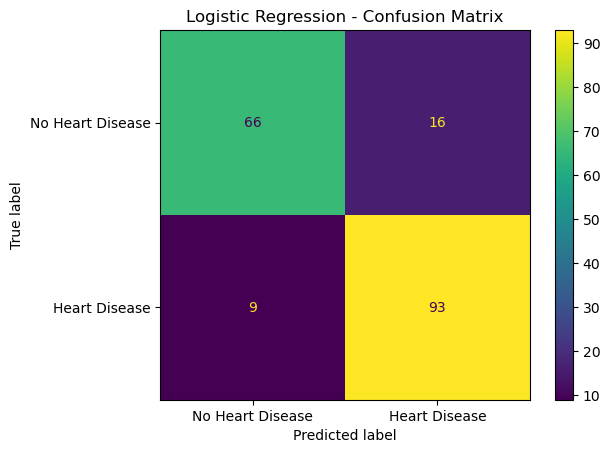

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Heart Disease", "Heart Disease"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

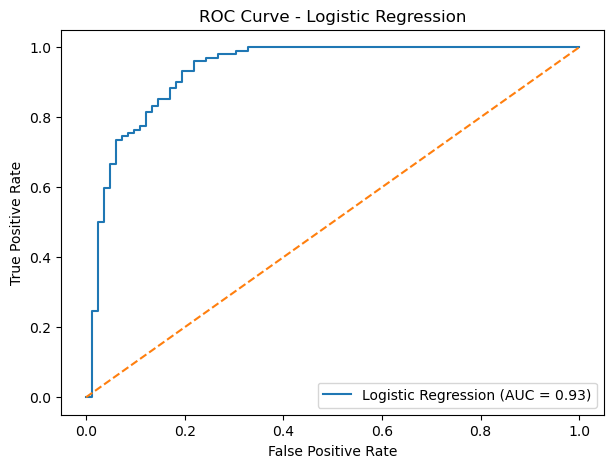

AUC: 0.9338


In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability predictions
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

# Calculate AUC
auc_lr = roc_auc_score(y_test, y_prob_lr)

# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("AUC:", round(auc_lr, 4))

In [16]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train the model
decision_tree.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [17]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("--------------------")
print("Accuracy :", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Recall   :", round(recall_dt, 4))

Decision Tree Results
--------------------
Accuracy : 0.8804
Precision: 0.8571
Recall   : 0.9412


Decision Tree Confusion Matrix:
[[66 16]
 [ 6 96]]


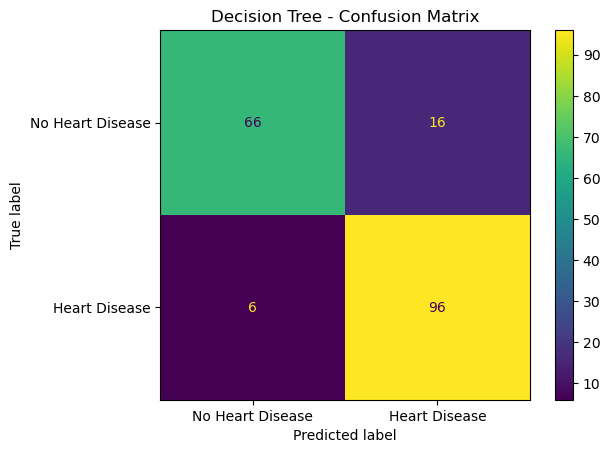

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Decision Tree Confusion Matrix:")
print(cm_dt)

disp_dt = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["No Heart Disease", "Heart Disease"]
)

disp_dt.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

# Decision Tree probabilities
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

# ROC values
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)

# AUC
auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree AUC:", round(auc_dt, 4))

Decision Tree AUC: 0.916


In [21]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy_lr, accuracy_dt],
    "Precision": [precision_lr, precision_dt],
    "Recall": [recall_lr, recall_dt],
    "AUC": [auc_lr, auc_dt]
})

results.round(4)

,Model,Accuracy,Precision,Recall,AUC
0,Logistic Regression,0.8641,0.8532,0.9118,0.9338
1,Decision Tree,0.8804,0.8571,0.9412,0.9160


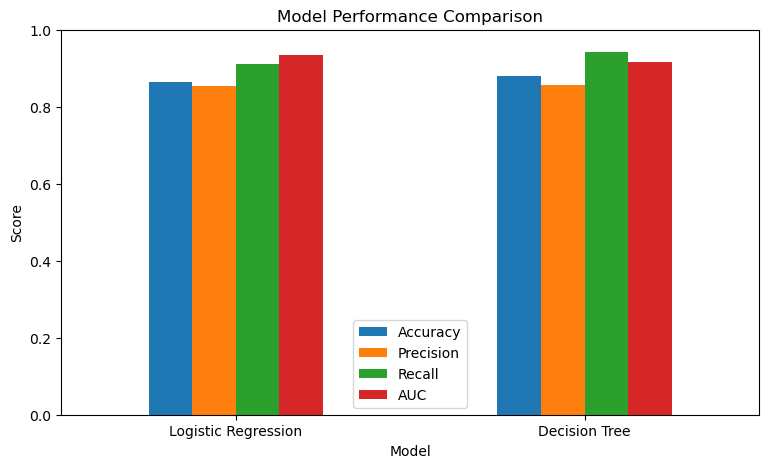

In [22]:
results.set_index("Model")[["Accuracy", "Precision", "Recall", "AUC"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [23]:
best_model = results.loc[results["Accuracy"].idxmax(), "Model"]

print("Best Model:", best_model)
print("Highest Accuracy:", round(results["Accuracy"].max(), 4))

Best Model: Decision Tree
Highest Accuracy: 0.8804


# Conclusion

This project developed machine learning models to predict the presence of heart disease.

Two models were evaluated:
- Logistic Regression
- Decision Tree

The models were evaluated using accuracy, precision, recall, confusion matrix, and ROC-AUC.

The Decision Tree achieved the highest accuracy of 88.04% on the test data and was selected as the better-performing model for this dataset.

Machine learning can be useful for identifying patterns in health data, but these predictions should not be treated as a medical diagnosis.